# Necessary Imports

In [18]:
import pickle
import warnings
from typing import Tuple, Any

import pandas as pd
import numpy as np
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Configure the notebook
pd.set_option("display.max_columns", None)
optuna.logging.set_verbosity(optuna.logging.ERROR)

RANDOM_STATE = 1994

Load the preprocessed dataset.

In [2]:
with open("preprocessed_dataset.pkl", "rb") as f:
    full_dataset = pickle.load(f)
full_dataset

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines:No,MultipleLines:No phone service,MultipleLines:Yes,OnlineSecurity:No,OnlineSecurity:No internet service,OnlineSecurity:Yes,OnlineBackup:No,OnlineBackup:No internet service,OnlineBackup:Yes,DeviceProtection:No,DeviceProtection:No internet service,DeviceProtection:Yes,TechSupport:No,TechSupport:No internet service,TechSupport:Yes,StreamingTV:No,StreamingTV:No internet service,StreamingTV:Yes,StreamingMovies:No,StreamingMovies:No internet service,StreamingMovies:Yes,InternetService:DSL,InternetService:Fiber optic,InternetService:No,Contract:Month-to-month,Contract:One year,Contract:Two year,PaymentMethod:Bank transfer (automatic),PaymentMethod:Credit card (automatic),PaymentMethod:Electronic check,PaymentMethod:Mailed check
0,0,0,1,0,-0.608696,0,1,-0.919468,-1.703665,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,0.108696,1,0,-0.228114,0.133600,0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,0,0,0,-0.586957,1,1,-0.288404,-1.139562,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0,0,0,0.347826,0,0,-0.547698,0.121937,0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,0,0,0,-0.586957,1,1,0.005366,-0.989818,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,-0.108696,1,1,0.202239,0.156835,0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
7039,0,0,1,1,0.934783,1,1,0.415304,0.740632,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7040,0,0,1,1,-0.391304,0,1,-0.928391,-0.622642,0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7041,1,1,1,0,-0.543478,1,1,0.060544,-0.677026,1,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


__Note__: the target column in the "Churn" column, which is __unbalanced__! We saw during the EDA and data processing steps that about 26.5% of the customers churned. This should be taken into account when a target metric is selected.

# Splitting the Dataset Into Train, Validation and Test Sets

First, define a three-way splitting function.

In [3]:
def tvt_splitter(
    x_data: np.ndarray, 
    y_data: np.ndarray,
    split_size1: float,
    split_size2: float
) -> Tuple[np.ndarray, ...]:

    x_train, x_buff, y_train, y_buff = train_test_split(x_data, y_data, test_size=split_size1, random_state=RANDOM_STATE)
    x_valid, x_test, y_valid, y_test = train_test_split(x_buff, y_buff, test_size=split_size2, random_state=RANDOM_STATE)

    return x_train, x_valid, x_test, y_train, y_valid, y_test

Then, perform the splitting.

In [4]:
x_train, x_valid, x_test, y_train, y_valid, y_test = tvt_splitter(
    x_data=full_dataset.drop(columns=["Churn"]).values,
    y_data=full_dataset["Churn"].values,
    split_size1=0.432,  # n_train = 4000, n_buff = 3043
    split_size2=0.3425  # n_valid = 2000, n_test = 1043
)
x_train.shape, x_valid.shape, x_test.shape, y_train.shape, y_valid.shape, y_test.shape

((4000, 40), (2000, 40), (1043, 40), (4000,), (2000,), (1043,))

# Setup Optuna

Due to the unbalanced nature of the target label, we shouldn't use accuracy as our target, but rather a more robust performance indicator, such as PR-AUC or F1. After a little bit of research, I found that the __Matthews correlation coefficient__ is an even better indicator for inbalanced datasets (see the [Wikipedia](https://en.wikipedia.org/wiki/Phi_coefficient#Advantages_over_accuracy_and_F1_score) article about it), so let's use that!

In [5]:
def calculate_score(classifier: Any, trial: optuna.Trial) -> float:

    classifier.fit(x_train, y_train)
    y_valid_pred = classifier.predict(x_valid)

    mcc = matthews_corrcoef(y_valid, y_valid_pred)
    f1 = f1_score(y_valid, y_valid_pred)
    acc = accuracy_score(y_valid, y_valid_pred)

    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    
    return mcc

Define the training objectives, just like in "homework5". The differences are:

- I have removed the KNN Classifier,
- we follow the accuracy and F1 scores too, but do not optimize for it

In [6]:
def lr_objective(trial: optuna.Trial) -> float:
    
    penalty = trial.suggest_categorical(
        "lr_penalty", ["None", "l1", "l2", "elasticnet"]
    )

    if penalty == "None":
        penalty = None
        inverse_regularization_strength = 1.0
        solver = "lbfgs"
        l1_ratio = None
    elif penalty == "l1":
        inverse_regularization_strength = trial.suggest_float("lr_l1_C", 1E-3, 1E3, log=True)
        solver = "liblinear"
        l1_ratio = None
    elif penalty == "l2":
        inverse_regularization_strength = trial.suggest_float("lr_l2_C", 1E-3, 1E3, log=True)
        solver = "lbfgs"
        l1_ratio = None
    elif penalty == "elasticnet":
        inverse_regularization_strength = trial.suggest_float("lr_elasticnet_C", 1E-3, 1E3, log=True)
        solver = "saga"
        l1_ratio = trial.suggest_float("lr_elasticnet_l1_ratio", 0.001, 0.999, log=False)
    else:
        raise Exception("Unreachable!")
        
    classifier = LogisticRegression(
        penalty=penalty,
        C=inverse_regularization_strength,
        l1_ratio=l1_ratio,
        solver=solver
    )
    return calculate_score(classifier, trial)


def dtc_objective(trial: optuna.Trial) -> float:
    
    criterion = trial.suggest_categorical(
        "dtc_criterion", ["gini", "entropy", "log_loss"]
    )

    if criterion == "gini":
        max_depth = trial.suggest_int("dtc_gini_max_depth", 2, 32, log=True)
        min_samples_leaf = trial.suggest_int("dtc_gini_min_samples_leaf", 1, 10, log=False)
    elif criterion == "entropy":
        max_depth = trial.suggest_int("dtc_entropy_max_depth", 2, 32, log=True)
        min_samples_leaf = trial.suggest_int("dtc_entropy_min_samples_leaf", 1, 10, log=False)
    elif criterion == "log_loss":
        max_depth = trial.suggest_int("dtc_log_loss_max_depth", 2, 32, log=True)
        min_samples_leaf = trial.suggest_int("dtc_log_loss_min_samples_leaf", 1, 10, log=False)
    else:
        raise Exception("Unreachable!")
        
    classifier = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf  
    )
    return calculate_score(classifier, trial)


def rfc_objective(trial: optuna.Trial) -> float:
    
    criterion = trial.suggest_categorical(
        "rfc_criterion", ["gini", "entropy", "log_loss"]
    )

    if criterion == "gini":
        n_estimators = trial.suggest_int("rfc_gini_n_estimators", 5, 100, log=False)
        max_depth = trial.suggest_int("rfc_gini_max_depth", 2, 32, log=True)
        min_samples_leaf = trial.suggest_int("rfc_gini_min_samples_leaf", 1, 10, log=False)
    elif criterion == "entropy":
        n_estimators = trial.suggest_int("rfc_entropy_n_estimators", 5, 100, log=False)
        max_depth = trial.suggest_int("rfc_entropy_max_depth", 2, 32, log=True)
        min_samples_leaf = trial.suggest_int("rfc_entropy_min_samples_leaf", 1, 10, log=False)
    elif criterion == "log_loss":
        n_estimators = trial.suggest_int("rfc_log_loss_n_estimators", 5, 100, log=False)
        max_depth = trial.suggest_int("rfc_log_loss_max_depth", 2, 32, log=True)
        min_samples_leaf = trial.suggest_int("rfc_log_loss_min_samples_leaf", 1, 10, log=False)
    else:
        raise Exception("Unreachable!")
        
    classifier = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf   
    )
    return calculate_score(classifier, trial)


def svc_objective(trial: optuna.Trial) -> float:
    
    kernel = trial.suggest_categorical(
        "svc_kernel", ["poly", "rbf", "sigmoid"]
    )

    if kernel == "poly":
        degree = trial.suggest_int("svc_poly_degree", 1, 4, log=False)
        inverse_regularization_strength = trial.suggest_float("svc_poly_C", 1E-3, 1E3, log=True)
        gamma = trial.suggest_categorical("svc_poly_gamma", ["scale", "auto"])
    elif kernel == "rbf":
        degree = 1.0
        inverse_regularization_strength = trial.suggest_float("svc_rbf_C", 1E-3, 1E3, log=True)
        gamma = trial.suggest_categorical("svc_rbf_gamma", ["scale", "auto"])
    elif kernel == "sigmoid":
        degree = 1.0
        inverse_regularization_strength = trial.suggest_float("svc_sigmoid_C", 1E-3, 1E3, log=True)
        gamma = trial.suggest_categorical("svc_sigmoid_gamma", ["scale", "auto"])
    else:
        raise Exception("Unreachable!")
        
    classifier = SVC(
        kernel=kernel,
        C=inverse_regularization_strength,
        gamma=gamma
    )
    return calculate_score(classifier, trial)


def objective(trial: optuna.Trial):

    classifier_name = trial.suggest_categorical(
        "classifier", [
            "LogisticRegression", "DecisionTreeClassifier", "RandomForestClassifier",
            "SVC"
        ]
    )

    if classifier_name == "LogisticRegression":
        return lr_objective(trial)
    elif classifier_name == "DecisionTreeClassifier":
        return dtc_objective(trial)
    elif classifier_name == "RandomForestClassifier":
        return rfc_objective(trial)
    elif classifier_name == "SVC":
        return svc_objective(trial)
    else:
        raise Exception("Unreachable!")

# Run Optuna

Perform the hyperparameter optimization.

In [7]:
new_best_parameters = set()

for iteration_idx in range(100):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # Store study in a persistent database in each iteration
        study = optuna.create_study(
            direction="maximize",
            storage="sqlite:///main_study.db",
            study_name="main_study",
            load_if_exists=True
        )
        study.optimize(objective, n_trials=100)

    # Print the current iteration and best parameter, if changed 
    best_params = frozenset(study.best_params.items())
    best_score = study.best_trial.value
    print(f"\rIteration {iteration_idx + 1} / 100 (best target score: {best_score:.3%})", end="")
    if best_params not in new_best_parameters:
        new_best_parameters.add(best_params)
        print(f" - new best parameters: {study.best_params}")

Iteration 1 / 100 (best target score: 47.887%) - new best parameters: {'classifier': 'RandomForestClassifier', 'rfc_criterion': 'gini', 'rfc_gini_n_estimators': 84, 'rfc_gini_max_depth': 25, 'rfc_gini_min_samples_leaf': 8}
Iteration 28 / 100 (best target score: 48.132%) - new best parameters: {'classifier': 'RandomForestClassifier', 'rfc_criterion': 'gini', 'rfc_gini_n_estimators': 57, 'rfc_gini_max_depth': 13, 'rfc_gini_min_samples_leaf': 5}
Iteration 100 / 100 (best target score: 48.132%)

# Optuna Result Analysis

Let's look at the sampled target score values.

In [9]:
optimization_score_classifier_table = pd.DataFrame({
    "mcc": [trial.values[0] for trial in study.trials if trial.values is not None],
    "f1": [trial.user_attrs["f1"] for trial in study.trials if trial.values is not None],
    "acc": [trial.user_attrs["acc"] for trial in study.trials if trial.values is not None],
    "classifier": [trial.params["classifier"] for trial in study.trials if trial.values is not None],
})
optimization_score_classifier_table

,mcc,f1,acc,classifier
0,0.396292,0.476309,0.7900,SVC
1,0.478872,0.590763,0.8095,RandomForestClassifier
2,0.239940,0.183639,0.7555,LogisticRegression
3,0.450777,0.575916,0.7975,LogisticRegression
4,0.443055,0.550562,0.8000,RandomForestClassifier
...,...,...,...,...
9995,0.465903,0.580645,0.8050,RandomForestClassifier
9996,0.453594,0.573561,0.8000,RandomForestClassifier
9997,0.448692,0.565547,0.7995,RandomForestClassifier
9998,0.426433,0.555438,0.7895,RandomForestClassifier


Text(0, 0.5, 'count')

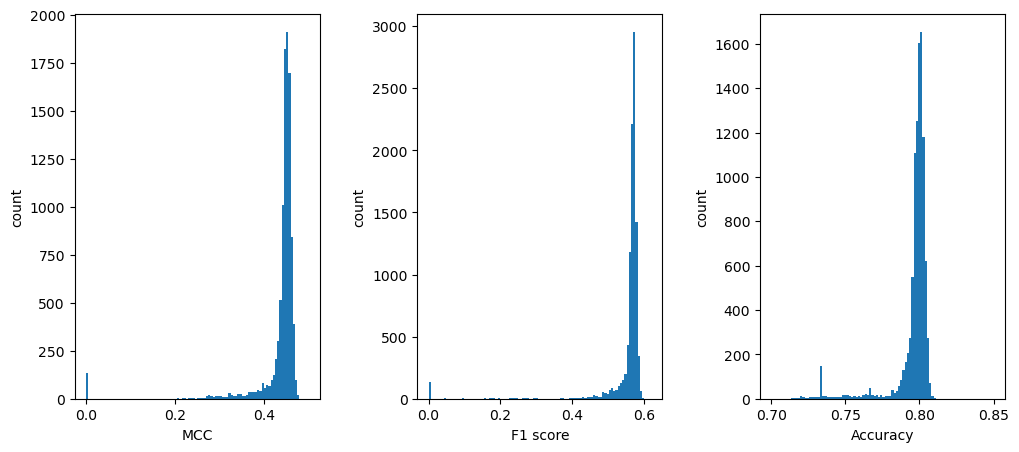

In [22]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(12, 5)
fig.subplots_adjust(wspace=0.4)

ax[0].hist(optimization_score_classifier_table["mcc"], bins=100, range=(0., 0.5))
ax[0].set_xlabel("MCC")
ax[0].set_ylabel("count")

ax[1].hist(optimization_score_classifier_table["f1"], bins=100, range=(0., 0.62))
ax[1].set_xlabel("F1 score")
ax[1].set_ylabel("count")

ax[2].hist(optimization_score_classifier_table["acc"], bins=100, range=(0.7, 0.85))
ax[2].set_xlabel("Accuracy")
ax[2].set_ylabel("count")

And also collect classifier-specific score distributions.

<Axes: xlabel='classifier', ylabel='acc'>

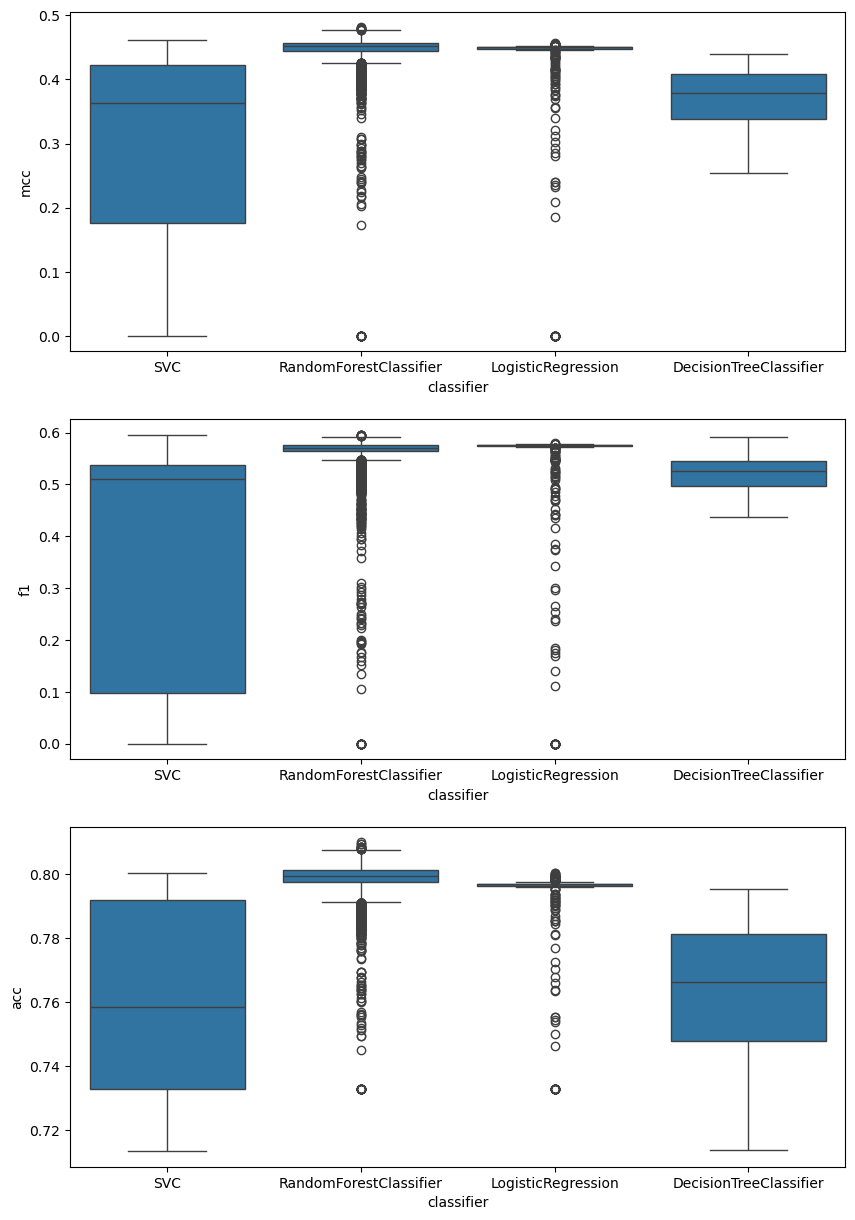

In [11]:
fig, ax = plt.subplots(3, 1)
fig.set_size_inches(10, 15)

sns.boxplot(optimization_score_classifier_table, x="classifier", y="mcc", ax=ax[0])
sns.boxplot(optimization_score_classifier_table, x="classifier", y="f1", ax=ax[1])
sns.boxplot(optimization_score_classifier_table, x="classifier", y="acc", ax=ax[2])

# Model and Hyperparameter Finalization

The best MCC, F1 score and accuracy values belong to the random forest classifier types. Let's look at the very best trial.

In [12]:
study.best_trial

FrozenTrial(number=2708, state=<TrialState.COMPLETE: 1>, values=[0.48132451041887553], datetime_start=datetime.datetime(2025, 12, 14, 19, 10, 37, 967200), datetime_complete=datetime.datetime(2025, 12, 14, 19, 10, 38, 289321), params={'classifier': 'RandomForestClassifier', 'rfc_criterion': 'gini', 'rfc_gini_n_estimators': 57, 'rfc_gini_max_depth': 13, 'rfc_gini_min_samples_leaf': 5}, user_attrs={'acc': 0.81, 'f1': 0.594017094017094}, system_attrs={}, intermediate_values={}, distributions={'classifier': CategoricalDistribution(choices=('LogisticRegression', 'DecisionTreeClassifier', 'RandomForestClassifier', 'SVC')), 'rfc_criterion': CategoricalDistribution(choices=('gini', 'entropy', 'log_loss')), 'rfc_gini_n_estimators': IntDistribution(high=100, log=False, low=5, step=1), 'rfc_gini_max_depth': IntDistribution(high=32, log=True, low=2, step=1), 'rfc_gini_min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1)}, trial_id=2709, value=None)

Recreate the classifier belonging to the best trial and validate it.

In [35]:
best_rfc = RandomForestClassifier(
    criterion=study.best_trial.params["rfc_criterion"],
    n_estimators=study.best_trial.params["rfc_gini_n_estimators"],
    max_depth=study.best_trial.params["rfc_gini_max_depth"],
    min_samples_leaf=study.best_trial.params["rfc_gini_min_samples_leaf"],
).fit(x_train, y_train)
best_rfc

,n_estimators,57
,criterion,'gini'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
best_rfc_y_train_pred = best_rfc.predict(x_train)
best_rfc_y_valid_pred = best_rfc.predict(x_valid)
best_rfc_y_test_pred = best_rfc.predict(x_test)

best_rfc_validation_table = pd.DataFrame({
    "mcc": [
        matthews_corrcoef(y_train, best_rfc_y_train_pred),
        matthews_corrcoef(y_valid, best_rfc_y_valid_pred),
        matthews_corrcoef(y_test, best_rfc_y_test_pred),
    ],
    "f1": [
        f1_score(y_train, best_rfc_y_train_pred),
        f1_score(y_valid, best_rfc_y_valid_pred),
        f1_score(y_test, best_rfc_y_test_pred),
    ],
    "acc": [
        accuracy_score(y_train, best_rfc_y_train_pred),
        accuracy_score(y_valid, best_rfc_y_valid_pred),
        accuracy_score(y_test, best_rfc_y_test_pred),
    ],
    "prec": [
        precision_score(y_train, best_rfc_y_train_pred),
        precision_score(y_valid, best_rfc_y_valid_pred),
        precision_score(y_test, best_rfc_y_test_pred),
    ],
    "rec": [
        recall_score(y_train, best_rfc_y_train_pred),
        recall_score(y_valid, best_rfc_y_valid_pred),
        recall_score(y_test, best_rfc_y_test_pred),
    ],
}, index=["train", "valid", "test", ])
best_rfc_validation_table

,mcc,f1,acc,prec,rec
train,0.620004,0.701174,0.860000,0.802198,0.622749
valid,0.458304,0.576017,0.802000,0.672500,0.503745
test,0.435848,0.554167,0.794823,0.665000,0.475000


Since we have a random forest classifier, we can look at the importance of different features and check whether they align with the info we found durint the EDA.

<Axes: ylabel='Mean decrease in impurity'>

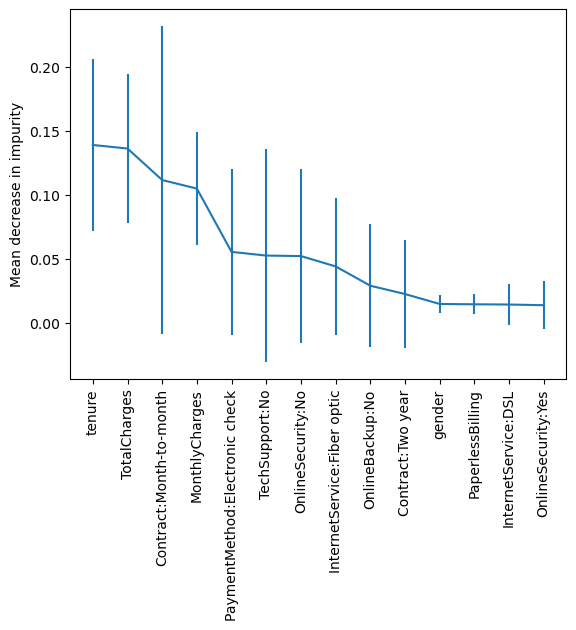

In [32]:
best_rfc_importances = best_rfc.feature_importances_
best_rfc_importances_std = np.std([tree.feature_importances_ for tree in best_rfc.estimators_], axis=0)
best_rfc_feature_names = full_dataset.drop(columns=["Churn"]).columns

best_rfc_importances_mask = np.argsort(best_rfc.feature_importances_)[:-15:-1]
best_rfc_importances = best_rfc_importances[best_rfc_importances_mask]
best_rfc_importances_std = best_rfc_importances_std[best_rfc_importances_mask]
best_rfc_feature_names = best_rfc_feature_names[best_rfc_importances_mask]

fig, ax = plt.subplots()
ax.errorbar(
    np.arange(len(best_rfc_importances)),
    best_rfc_importances,
    yerr=best_rfc_importances_std
)
ax.set_xticks(np.arange(len(best_rfc_importances)), labels=best_rfc_feature_names, rotation=90)
ax.set_ylabel("Mean decrease in impurity")
ax